# Mean bias correction

In [6]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import cmcrameri.cm as cmc  # noqa: F401
from tqdm.auto import tqdm
from icecream import ic
import yaml
import cartopy.crs as ccrs
import dask
from analyses.utils import load_datasets_and_configs
from matplotlib import gridspec
from unseen_awg.plotting_utils import (
    map_plot_without_frame_with_bounds,
    add_headers,
    add_label_to_axes,
)

from metpy.units import units

In [7]:
dask.config.set(num_workers=3)

In [8]:
mpl.rc_file("../../matplotlibrc")
with open("../../configs/paths.yaml") as file:
    paths = yaml.safe_load(file)["paths"]

ALPHABET = "abcdefghij"

## For a single lead time the distribution of time steps over the days of the year isn't very uniform

This is what makes it necessary to fill missing values in the bias correction computation'

In [9]:
def get_bias(clim, clim_ref):
    res = xr.Dataset()

    for var in clim.data_vars:
        if var in [
            r"$T_\mathrm{2m, mean}$",
            r"$T_\mathrm{2m, max}$",
            r"$T_\mathrm{2m, min}$",
        ]:
            res[var] = clim[var] - clim_ref[var]
        elif var == r"$P$":
            res[var] = (clim[var] / clim_ref[var] - 1) * 100
        else:
            raise ValueError(f"Invalid variable: {var}")

    return res

In [10]:
ds_era5_rechunk = xr.open_zarr(
    os.path.join(
        paths["dir_preprocessed_datasets"],
        "preprocessed_impact_variables_era5",
        "rechunk_combined_facc0e91.zarr",
    ),
    decode_timedelta=True,
).squeeze()

ds_reforecasts_rechunk = xr.open_zarr(
    os.path.join(
        paths["dir_preprocessed_datasets"],
        "preprocessed_impact_variables_reforecasts",
        "combined-corrected_facc0e91_7d1d3d97_884a804a_3f7e331d.zarr",
    ),
    decode_timedelta=True,
)

ds_reforecasts_rechunk = ds_reforecasts_rechunk.assign_coords(
    valid_time=ds_reforecasts_rechunk["init_time"] + ds_reforecasts_rechunk["lead_time"]
)
ds_era5_rechunk = ds_era5_rechunk.assign_coords(
    valid_time=ds_era5_rechunk["init_time"].drop_vars("init_time")
    + ds_era5_rechunk["lead_time"]
).drop_vars(("init_time", "lead_time"))
ds_era5_rechunk = ds_era5_rechunk.swap_dims({"lead_time": "valid_time"})


ds_era5_rechunk["tp"] = (
    ds_era5_rechunk["tp"]
    .where(ds_era5_rechunk["tp"].metpy.quantify() > 1 * units.millimeter, 0)
    .metpy.dequantify()
)

ds_reforecasts_rechunk["tp"] = (
    ds_reforecasts_rechunk["tp"]
    .where(ds_reforecasts_rechunk["tp"].metpy.quantify() > 1 * units.millimeter, 0)
    .metpy.dequantify()
)

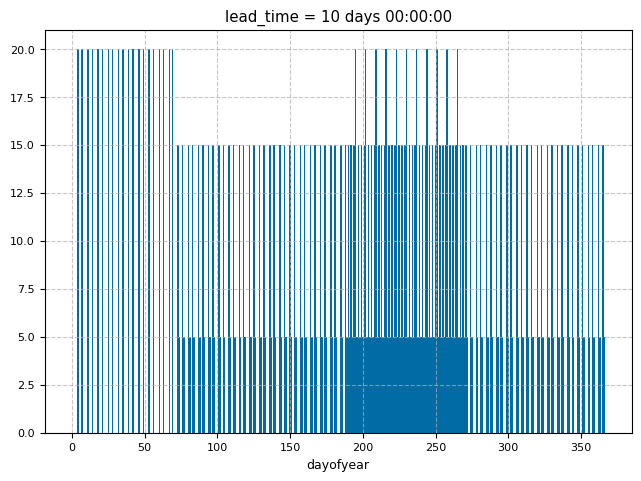

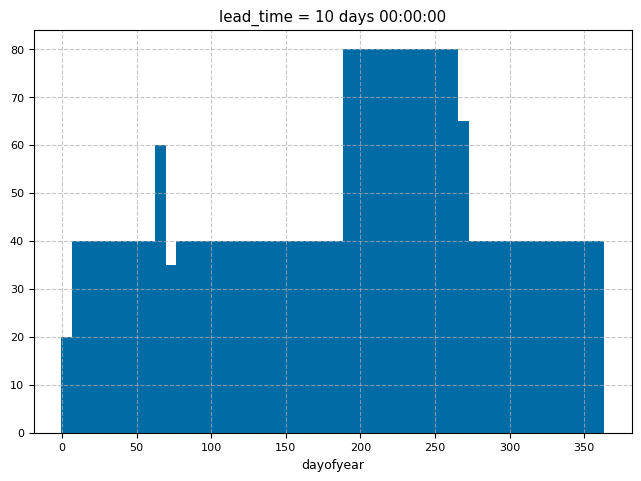

In [11]:
i_lead_time = 10

ds_re_single_lt = ds_reforecasts_rechunk.isel(lead_time=i_lead_time).swap_dims(
    {"init_time": "valid_time"}
)

ds_re_single_lt.valid_time.dt.dayofyear.plot.hist(bins=np.arange(-0.5, 367.5))
plt.show()

ds_re_single_lt.valid_time.dt.dayofyear.plot.hist(bins=np.arange(-0.5, 367.5, 7))
plt.show()

# Analyzing the bias

The bias is precomputed in a separate script. Here we analyze the biases and test, how reliably we can determine the bias. To do so, we split the dataset into several chunks. We test 3 splitting strategies:

- splitting init times `chronological`ly, i.e. once using the first half of the data points in the dataset, the second one using the later half. This might be susceptible to changes of bias with climate change.
- fully `random` split of init times. Potentially, this underestimates the variability of the bias estimates because for each initial time step in set A, we will likely find an initial condition from a similar time in set B.
- randomly split years (`random_years`). Should mitigate the climate change effect while limiting the dependence that would come with a fully random split

In [12]:
dir_bias = "preprocessed_impact_variables_reforecasts/bias_facc0e91_7d1d3d97_99914b93"
SPLIT_MODES = ["random-years", "random", "chronological"]
clim_reforecasts = []
clim_era5 = []

for split_mode in SPLIT_MODES:
    clim_reforecasts.append(
        xr.open_zarr(
            os.path.join(
                paths["dir_preprocessed_datasets"],
                f"{dir_bias}/reforecasts_mode_{split_mode}_n_2.zarr",
            )
        )
    )
    clim_era5.append(
        xr.open_zarr(
            os.path.join(
                paths["dir_preprocessed_datasets"],
                f"{dir_bias}/era5_mode_{split_mode}_n_2.zarr",
            )
        )
    )

rename_vars = {
    "t2m": r"$T_\mathrm{2m, mean}$",
    "mx2t": r"$T_\mathrm{2m, max}$",
    "mn2t": r"$T_\mathrm{2m, min}$",
    "tp": r"$P$",
}
rerename_vars = {v: k for (k, v) in rename_vars.items()}

clim_reforecasts = xr.combine_by_coords(clim_reforecasts)
clim_era5 = xr.combine_by_coords(clim_era5)

clim_reforecasts = clim_reforecasts.rename(rename_vars)
clim_era5 = clim_era5.rename(rename_vars)

First, look at bias for a single random location:

In [13]:
n = 5
idcs_lat = xr.DataArray(
    np.random.choice(len(clim_reforecasts.latitude), size=n),
    dims="location",
)
idcs_lon = xr.DataArray(
    np.random.choice(len(clim_reforecasts.longitude), size=n),
    dims="location",
)


clim_reforecasts_single_loc = clim_reforecasts.isel(
    latitude=idcs_lat, longitude=idcs_lon
).load()
clim_era5_single_loc = clim_era5.isel(latitude=idcs_lat, longitude=idcs_lon).load()

ic(
    clim_reforecasts.latitude.isel(latitude=idcs_lat),
    clim_reforecasts.longitude.isel(longitude=idcs_lon),
)

bias_few_locs = get_bias(
    clim=clim_reforecasts_single_loc, clim_ref=clim_era5_single_loc
)

ic| clim_reforecasts.latitude.isel(latitude=idcs_lat): <xarray.DataArray 'latitude' (location: 5)> Size: 40B
                                                       array([31. , 46.6, 37. , 57.4, 47.8])
                                                       Coordinates:
                                                           latitude  (location) float64 40B 31.0 46.6 37.0 57.4 47.8
                                                       Dimensions without coordinates: location
    clim_reforecasts.longitude.isel(longitude=idcs_lon): <xarray.DataArray 'longitude' (location: 5)> Size: 40B
                                                         array([29.8, 17. , 33.8, 19. , 28.2])
                                                         Coordinates:
                                                             longitude  (location) float64 40B 29.8 17.0 33.8 19.0 28.2
                                                         Dimensions without coordinates: location


At first, one would expect the ERA5 biases to be independent of lead time. 

However, there are differences, particularly in winter because we subset ERA5 to the time steps on which we also have forecasts. And which ones this entails varies with lead time. Particularly in winter, for which we have relatively few init times (see Figure above).

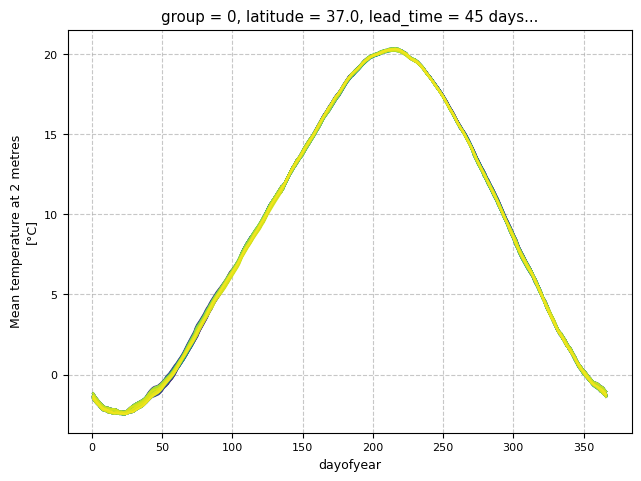

In [14]:
var = r"$T_\mathrm{2m, mean}$"

cmap = plt.get_cmap("viridis")

for i, lt in enumerate(clim_era5_single_loc.lead_time):
    color = cmap(i / len(clim_reforecasts.lead_time))
    clim_era5_single_loc.sel(lead_time=lt).isel(group=0, location=2, split_mode=0)[
        var
    ].plot(color=color)

Comparing biases between for a given variable and type of splitting the data before computing the bias:

In [15]:
from matplotlib.cm import ScalarMappable

cmaps = [plt.get_cmap("Reds"), plt.get_cmap("Blues")]

var = r"$T_\mathrm{2m, mean}$"

split_mode = "chronological"

for loc in bias_few_locs.location:
    fig, ax = plt.subplots()

    for j, group in enumerate(
        bias_few_locs.group.isel(group=slice(0, 2))
    ):  # show results from two different groups
        for i, lt in enumerate(bias_few_locs.lead_time):
            color = cmaps[j](i / len(clim_reforecasts.lead_time))
            bias_few_locs.sel(split_mode=split_mode, location=loc).isel(
                group=group
            ).sel(lead_time=lt)[var].plot(ax=ax, color=color)

            sm = ScalarMappable(
                cmap=cmaps[j],
                norm=plt.Normalize(vmin=0, vmax=len(bias_few_locs.lead_time)),
            )
    # plt.show()
    plt.close()

Another possible visualization is fixing the `lead_time` or `dayofyear`and looking at map plots of the bias:

In [16]:
i_lead_time = 40
slice_dayofyear = slice(None, None, 100)

In [ ]:
bias_single_lt = get_bias(
    clim=clim_reforecasts.isel(lead_time=i_lead_time, dayofyear=slice_dayofyear),
    clim_ref=clim_era5.isel(lead_time=i_lead_time, dayofyear=slice_dayofyear),
).load(num_workers=3)

In [18]:
cmap_norm = {
    r"$T_\mathrm{2m, mean}$": {
        "norm": plt.Normalize(vmin=-3, vmax=3),
        "cmap": "cmc.vik",
    },
    r"$T_\mathrm{2m, min}$": {
        "norm": plt.Normalize(vmin=-3, vmax=3),
        "cmap": "cmc.vik",
    },
    r"$T_\mathrm{2m, max}$": {
        "norm": plt.Normalize(vmin=-3, vmax=3),
        "cmap": "cmc.vik",
    },
    r"$P$": {"norm": plt.Normalize(vmin=-100, vmax=100), "cmap": "cmc.broc_r"},
}

unit_bias = {
    r"$T_\mathrm{2m, mean}$": "K",
    r"$T_\mathrm{2m, min}$": "K",
    r"$T_\mathrm{2m, max}$": "K",
    r"$P$": "%",
}

In [19]:
for var in bias_single_lt.data_vars:
    for split_mode in bias_single_lt.split_mode:
        # for split_mode in bias_single_lt.split_mode:
        fig = plt.figure()
        fig.set_figheight(10)
        gs = fig.add_gridspec(
            len(bias_single_lt.dayofyear) + 1,
            len(bias_single_lt.group),
            height_ratios=len(bias_single_lt.dayofyear)
            * [
                1,
            ]
            + [0.1],
        )

        ax_cbar = fig.add_subplot(gs[-1, :])

        for i, doy in enumerate(bias_single_lt.dayofyear):
            for j, group in enumerate(bias_single_lt.group):
                ax = fig.add_subplot(gs[i, j], projection=ccrs.Robinson())
                m = map_plot_without_frame_with_bounds(
                    ax=ax,
                    da=bias_single_lt.sel(
                        dayofyear=doy, split_mode=split_mode, group=group
                    )[var],
                    **cmap_norm[var],
                    add_colorbar=False,
                )
                m.set_rasterized(True)
                ax.set_title("")
                add_label_to_axes(
                    ax,
                    label=f"({ALPHABET[i + j * len(bias_single_lt.data_vars)]})",
                    va="bottom",
                    ha="left",
                    ax_xpos=0.05,
                    ax_ypos=0.05,
                )
        add_headers(
            fig,
            col_headers=[f"Subset {g.data + 1}" for g in bias_single_lt.group],
            row_headers=[f"Dayofyear = {doy.data}" for doy in bias_single_lt.dayofyear]
            + [""],
            col_pad=15,
        )

        plt.colorbar(
            m,
            cax=ax_cbar,
            orientation="horizontal",
            label=f"{var} bias [{unit_bias[var]}]",
        )

        plt.savefig(
            os.path.join(
                paths["dir_images"],
                f"bias_fixed_lead_time_{rerename_vars[var]}_{split_mode.data}.pdf",
            ),
            dpi=300,
        )
        plt.close()

We can attempt the same for a single dayofyear varying `lead_time`:

In [20]:
doy = 1
slice_lead_time = slice(None, None, 14)

In [ ]:
bias_single_doy = get_bias(
    clim=clim_reforecasts.isel(lead_time=slice_lead_time).sel(dayofyear=doy),
    clim_ref=clim_era5.isel(lead_time=slice_lead_time).sel(dayofyear=doy),
).load(num_workers=3)

In [22]:
for var in bias_single_doy.data_vars:
    for split_mode in bias_single_doy.split_mode:
        # for split_mode in bias_single_doy.split_mode:
        fig = plt.figure()
        fig.set_figheight(10)
        gs = fig.add_gridspec(
            len(bias_single_doy.lead_time) + 1,
            len(bias_single_doy.group),
            height_ratios=len(bias_single_doy.lead_time) * [1] + [0.1],
        )

        ax_cbar = fig.add_subplot(gs[-1, :])

        for i, lt in enumerate(bias_single_doy.lead_time):
            for j, group in enumerate(bias_single_doy.group):
                ax = fig.add_subplot(gs[i, j], projection=ccrs.Robinson())
                m = map_plot_without_frame_with_bounds(
                    ax=ax,
                    da=bias_single_doy.sel(
                        lead_time=lt, split_mode=split_mode, group=group
                    )[var],
                    **cmap_norm[var],
                    add_colorbar=False,
                )
                m.set_rasterized(True)
                ax.set_title("")
                add_label_to_axes(
                    ax,
                    label=f"({ALPHABET[i + j * len(bias_single_lt.data_vars)]})",
                    va="bottom",
                    ha="left",
                    ax_xpos=0.05,
                    ax_ypos=0.05,
                )
        add_headers(
            fig,
            col_headers=[f"Subset {g.data + 1}" for g in bias_single_doy.group],
            row_headers=[
                r"$t_\mathrm{lead}$=" + f"{int((lt / np.timedelta64(1, 'D')).data)}d"
                for lt in bias_single_doy.lead_time
            ]
            + [""],
            col_pad=15,
        )

        plt.colorbar(
            m,
            cax=ax_cbar,
            orientation="horizontal",
            label=f"{var} bias [{unit_bias[var]}]",
        )

        plt.savefig(
            os.path.join(
                paths["dir_images"],
                f"bias_fixed_dayofyear_{rerename_vars[var]}_{split_mode.data}.pdf",
            ),
            dpi=300,
        )
        plt.close()

## Looking at histograms of bias values:

In [ ]:
for var in [r"$T_\mathrm{2m, mean}$", r"$T_\mathrm{2m, min}$", r"$T_\mathrm{2m, max}$"]:
    bias = (clim_reforecasts - clim_era5)[var]

    # Compute min, max, and nan check together
    vmin, vmax, has_nans = dask.compute(bias.min(), bias.max(), bias.isnull().any())

    vmin = vmin.item()
    vmax = vmax.item()
    has_nans = has_nans.item()

    # Define bins
    bins = np.arange(np.floor(vmin), np.ceil(vmax) + 1)

    # Compute histogram using Dask (memory-efficient)
    counts, bin_edges = dask.array.histogram(bias.data, bins=bins)
    counts = counts.compute()  # Only load the histogram counts (much smaller)

    # Plot the histogram manually
    plt.figure()
    plt.bar(
        bin_edges[:-1],
        counts,
        width=np.diff(bin_edges),
        align="edge",
        edgecolor="black",
    )

    plt.title(f"{var} bias, max: {vmax:.1f}K, min: {vmin:.1f}K")
    plt.xlabel(var)
    plt.ylabel("Frequency")
    plt.axvline(x=0, linestyle="dashed", color="r")
    plt.show()

    print(f"{var}: Does Bias contain any nans?", has_nans)


In [ ]:
for var in [r"$T_\mathrm{2m, mean}$", r"$T_\mathrm{2m, min}$", r"$T_\mathrm{2m, max}$"]:
    # Compute the bias once and keep it as a dask array
    bias = (clim_reforecasts - clim_era5)[var]

    # Compute min, max, and nan check together (single pass through data)
    vmin, vmax, has_nans = dask.compute(bias.min(), bias.max(), bias.isnull().any())

    # Convert to scalar values
    vmin = vmin.item()
    vmax = vmax.item()
    has_nans = has_nans.item()

    # Plot histogram (this will trigger another computation)
    bias.plot.hist(bins=np.arange(np.floor(vmin), np.ceil(vmax) + 1))

    plt.title(f"{var} bias, max: {vmax:.1f}K, min: {vmin:.1f}K")
    plt.axvline(x=0, linestyle="dashed", color="r")
    plt.show()

    print(f"{var}: Does Bias contain any nans?", has_nans)

In [ ]:
var = "$P$"
bias = (clim_reforecasts / clim_era5)[var]

# Compute min, max, and nan check together
vmin, vmax, has_nans = dask.compute(bias.min(), bias.max(), bias.isnull().any())

vmin = vmin.item()
vmax = vmax.item()
has_nans = has_nans.item()

# Define bins
bins = np.linspace(0, 5, 51)

# Compute histogram using Dask (memory-efficient)
counts, bin_edges = dask.array.histogram(bias.data, bins=bins)
counts = counts.compute()  # Only load the histogram counts (much smaller)

# Plot the histogram manually
plt.figure()
plt.bar(
    bin_edges[:-1],
    counts,
    width=np.diff(bin_edges),
    align="edge",
    edgecolor="black",
)

plt.axvline(x=1, linestyle="dashed", color="r")

plt.title(f"{var}, max: {vmax * 100:.1f}%, min: {vmin * 100:.1f}%")

plt.show()

print(f"{var}: Does Bias contain any nans?", has_nans)